# Proyek Machine Learning - Klasifikasi
**Nama:** Muhammad Dhiyaul Atha

## Penting
Notebook ini berisi proses klasifikasi menggunakan data hasil clustering.

## 1. Import Library

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Memuat Dataset dari Hasil Clustering

**Metode:** Memuat `data_clustering.csv` yang merupakan output dari proses clustering.

In [12]:
df = pd.read_csv('data_clustering.csv')
print(f"Shape: {df.shape}")
print(f"Kolom: {list(df.columns)}")
df.head()

Shape: (1501, 10)
Kolom: ['TransactionAmount', 'TransactionType', 'Location', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'Target']


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,0
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,2
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,3
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,3
4,92.15,1,28,0,18.0,3,172.0,1.0,781.68,3


### Feature Encoding Tambahan

In [13]:
# Cek apakah ada kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if len(cat_cols) > 0:
    from sklearn.preprocessing import LabelEncoder
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col])
    print(f"Encoded: {cat_cols}")
else:
    print("Tidak ada kolom kategorikal")

Tidak ada kolom kategorikal


## 3. Data Splitting

**Metode:** `train_test_split()` dengan rasio 80:20.
**Alasan:** Standar umum untuk pembagian data training dan testing.

In [14]:
X = df.drop(columns=['Target'])
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (1200, 9)
X_test:  (301, 9)


## 4. Membangun Model Klasifikasi

**Metode:** Decision Tree Classifier.
**Alasan:** Mudah diinterpretasi dan cocok untuk klasifikasi multi-class.

=== Decision Tree ===
Accuracy:  0.9070
Precision: 0.9105
Recall:    0.9070
F1-Score:  0.9081

              precision    recall  f1-score   support

           0       0.92      0.88      0.90        67
           1       0.72      0.83      0.77        35
           2       0.89      0.91      0.90        64
           3       0.99      0.99      0.99        69
           4       0.94      0.89      0.91        66

    accuracy                           0.91       301
   macro avg       0.89      0.90      0.89       301
weighted avg       0.91      0.91      0.91       301



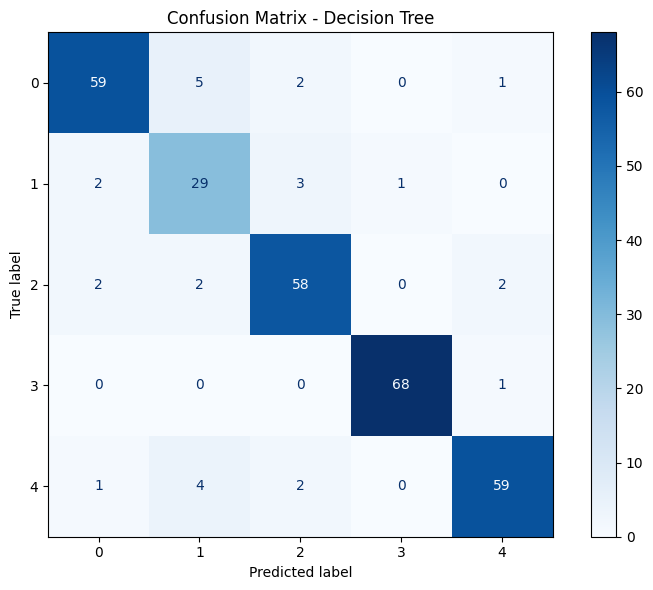

In [15]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"\n{classification_report(y_test, y_pred_dt)}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

# Simpan model Decision Tree
joblib.dump(dt_model, 'decision_tree_model.h5')
print("✅ Disimpan: decision_tree_model.h5")

### Penilaian
## 5. Memenuhi Kriteria Skilled dan Advanced

#### Algoritma Tambahan: Random Forest

**Metode:** Random Forest sebagai perbandingan dengan Decision Tree.
**Alasan:** Random Forest lebih robust terhadap overfitting.

=== Random Forest ===
Accuracy:  0.9502
Precision: 0.9500
Recall:    0.9502
F1-Score:  0.9500

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        67
           1       0.88      0.86      0.87        35
           2       0.95      0.95      0.95        64
           3       0.99      0.99      0.99        69
           4       0.95      0.95      0.95        66

    accuracy                           0.95       301
   macro avg       0.94      0.94      0.94       301
weighted avg       0.95      0.95      0.95       301



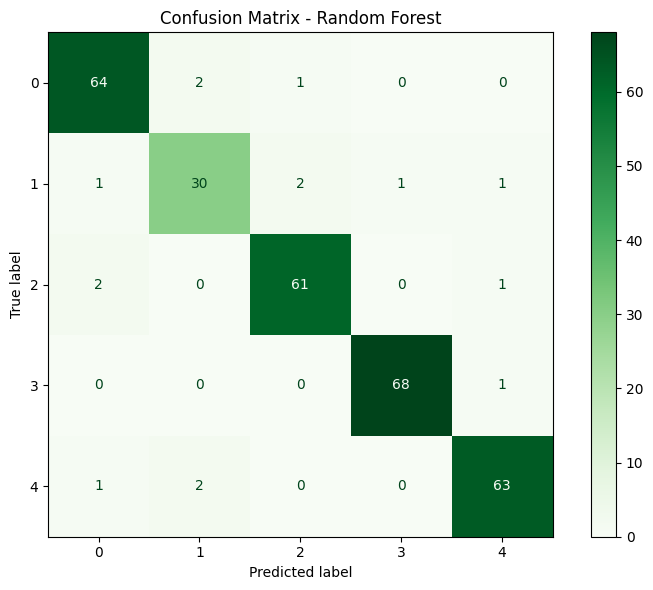

✅ Disimpan: explore_random_forest_classification


In [16]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf)}")

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

# Simpan model Random Forest
joblib.dump(rf_model, 'explore_random_forest_classification')
print("✅ Disimpan: explore_random_forest_classification")

In [17]:
# Perbandingan semua model
print("=== PERBANDINGAN MODEL ===")
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_dt, average='weighted'), precision_score(y_test, y_pred_rf, average='weighted')],
    'Recall': [recall_score(y_test, y_pred_dt, average='weighted'), recall_score(y_test, y_pred_rf, average='weighted')],
    'F1-Score': [f1_score(y_test, y_pred_dt, average='weighted'), f1_score(y_test, y_pred_rf, average='weighted')]
})
print(comparison.to_string(index=False))

=== PERBANDINGAN MODEL ===
        Model  Accuracy  Precision   Recall  F1-Score
Decision Tree  0.906977   0.910491 0.906977  0.908107
Random Forest  0.950166   0.949971 0.950166  0.950036


### Penilaian
#### Hyperparameter Tuning

**Metode:** GridSearchCV pada Decision Tree.
**Alasan:** Mencari kombinasi parameter terbaik untuk meningkatkan performa model.

In [18]:
# Hyperparameter Tuning - Decision Tree
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluasi model tuning
y_pred_tuned = grid_search.predict(X_test)
print(f"\n=== Tuned Decision Tree ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")
print(f"\n{classification_report(y_test, y_pred_tuned)}")

# Simpan model tuning
joblib.dump(grid_search.best_estimator_, 'tuning_classification')
print("\n✅ Disimpan: tuning_classification")

Best Parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Score: 0.9408

=== Tuned Decision Tree ===
Accuracy:  0.9236
Precision: 0.9233
Recall:    0.9236
F1-Score:  0.9231

              precision    recall  f1-score   support

           0       0.90      0.93      0.91        67
           1       0.84      0.77      0.81        35
           2       0.89      0.92      0.91        64
           3       0.99      0.99      0.99        69
           4       0.95      0.94      0.95        66

    accuracy                           0.92       301
   macro avg       0.92      0.91      0.91       301
weighted avg       0.92      0.92      0.92       301


✅ Disimpan: tuning_classification
